In [1]:
#Import libraries
import pandas as pd
from simpledbf import Dbf5
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from scipy.stats import gaussian_kde
import numpy as np
from scipy.stats import mstats
import seaborn as sns
import matplotlib.colors as mcolors
from scipy.stats import linregress

In [54]:
!pip install lightning

   ---------------------------------------- 0.0/827.9 kB ? eta -:--:--
   ------------------------------------- -- 786.4/827.9 kB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 827.9/827.9 kB 4.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/983.2 kB ? eta -:--:--
   ---------------------------------------- 983.2/983.2 kB 4.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/831.6 kB ? eta -:--:--
   ---------------------------------------- 831.6/831.6 kB 4.2 MB/s eta 0:00:00

   ---------------------------------------- 0/4 [lightning-utilities]
   ---------- ----------------------------- 1/4 [torchmetrics]
   ---------- ----------------------------- 1/4 [torchmetrics]
   ---------- ----------------------------- 1/4 [torchmetrics]
   ---------- ----------------------------- 1/4 [torchmetrics]
   ---------- ----------------------------- 1/4 [torchmetrics]
   ---------- ----------------------------- 1/4 [torchmetrics]
   ---------- ----

# Data Exploration

In [2]:
#Loading Data
property_locations = pd.read_csv('KDC Insurance Property Locations.csv')
property_codes = pd.read_excel('KDC Insurance Property Type Codes.xlsx')

In [3]:
#Inspecting Data
print(property_locations.shape)
print()
property_locations.head()

(821538, 12)



,Address_Line_1,City,ZIP,County,Sale Price,Market Value,Latitude,Longitude,Property Type,Coverage_Building %,Coverage_Contents %,Coverage_Outbuildings %
0,195 WINSTON LN,inlet beach,32461.0,Walton County,575100.0,1691277.0,30.254600,-85.95790,45,80,5,5
1,6456 AUTUMN WOODS BLVD,naples,34109.0,Collier County,397000.0,386932.0,26.218681,-81.78630,92,95,0,15
2,1723 GINGER CT,middleburg,32068.0,Clay County,42900.0,123045.0,30.111518,-81.78130,109,95,15,20
3,931 NAUTILUS ISLE,dania,33004.0,Broward County,125000.0,419770.0,26.061326,-80.15371,167,75,0,20
4,590 HOOKER TER,bartow,33830.0,Polk County,10500.0,59706.0,27.888814,-81.84673,45,85,5,0


In [4]:
#Inspecting Data
print(property_codes.shape)
print()
property_codes

(5, 2)



,Property Type,Property Type Code
0,Single Family Residence,167
1,Condominiums,45
2,Business,92
3,Agriculture,2
4,Government,109


In [5]:
#Merging excel and csv on Property Type Code
property_locations.rename(columns={"Property Type": "Property Type Code"}, inplace = True)
property_df = pd.merge(property_locations, property_codes, on = "Property Type Code")
property_df.head()

,Address_Line_1,City,ZIP,County,Sale Price,Market Value,Latitude,Longitude,Property Type Code,Coverage_Building %,Coverage_Contents %,Coverage_Outbuildings %,Property Type
0,195 WINSTON LN,inlet beach,32461.0,Walton County,575100.0,1691277.0,30.254600,-85.95790,45,80,5,5,Condominiums
1,6456 AUTUMN WOODS BLVD,naples,34109.0,Collier County,397000.0,386932.0,26.218681,-81.78630,92,95,0,15,Business
2,1723 GINGER CT,middleburg,32068.0,Clay County,42900.0,123045.0,30.111518,-81.78130,109,95,15,20,Government
3,931 NAUTILUS ISLE,dania,33004.0,Broward County,125000.0,419770.0,26.061326,-80.15371,167,75,0,20,Single Family Residence
4,590 HOOKER TER,bartow,33830.0,Polk County,10500.0,59706.0,27.888814,-81.84673,45,85,5,0,Condominiums


In [6]:
#Check Missing values 
for column in property_df.columns:
    missing_data_count = property_df[column].isnull().sum()
    print(f"Column '{column}': {missing_data_count} missing values")

Column 'Address_Line_1': 0 missing values
Column 'City': 25 missing values
Column 'ZIP': 36 missing values
Column 'County': 26 missing values
Column 'Sale Price': 345623 missing values
Column 'Market Value': 477 missing values
Column 'Latitude': 19018 missing values
Column 'Longitude': 19018 missing values
Column 'Property Type Code': 0 missing values
Column 'Coverage_Building %': 0 missing values
Column 'Coverage_Contents %': 0 missing values
Column 'Coverage_Outbuildings %': 0 missing values
Column 'Property Type': 0 missing values


In [7]:
#Loading Data
dbf_file_path = '2022092818_wsp64knt120hr_5km.dbf'
dbf = Dbf5(dbf_file_path)
dbf = dbf.to_dataframe()

shp_file_path = '2022092818_wsp64knt120hr_5km.shp'
shp = gpd.read_file(shp_file_path)

prj_file_path = '2022092818_wsp64knt120hr_5km.prj'

with open(prj_file_path, 'r') as prj_file:
    prj_contents = prj_file.read()

In [8]:
#Inspecting Data
print(dbf)
print()
print(shp)
print()
print(prj_contents)

   PERCENTAGE
0         <5%
1       5-10%
2      10-20%
3      20-30%
4      30-40%
5      40-50%
6      50-60%
7      60-70%
8      70-80%
9      80-90%
10       >90%

   PERCENTAGE                                           geometry
0         <5%  MULTIPOLYGON (((-228.53084 23.88258, -228.5308...
1       5-10%  MULTIPOLYGON (((-228.35102 24.60187, -228.3510...
2      10-20%  MULTIPOLYGON (((-227.99137 24.87161, -227.9913...
3      20-30%  MULTIPOLYGON (((-227.99137 25.68081, -227.9913...
4      30-40%  MULTIPOLYGON (((-82.46898 26.04046, -82.46898 ...
5      40-50%  MULTIPOLYGON (((-82.46898 26.13037, -82.46898 ...
6      50-60%  MULTIPOLYGON (((-82.46898 26.22028, -82.46898 ...
7      60-70%  MULTIPOLYGON (((-82.37907 26.26524, -82.37907 ...
8      70-80%  MULTIPOLYGON (((-82.46898 26.35515, -82.46898 ...
9      80-90%  MULTIPOLYGON (((-82.46898 26.40011, -82.46898 ...
10       >90%  MULTIPOLYGON (((-82.33411 26.44506, -82.33411 ...

GEOGCS["GCS_Sphere",DATUM["D_Sphere",SPHEROID["Sph

<Axes: >

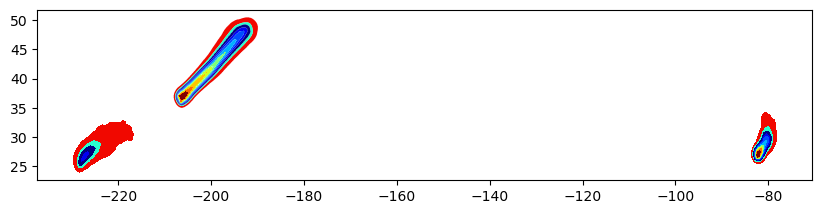

In [9]:
#Plot of hurricane
shp.plot(cmap = 'jet', column = 'PERCENTAGE', figsize = (10,10))

In [10]:
import geopandas as gpd
import geodatasets

# Load the world map (Natural Earth dataset)
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

# Define the range of longitude and latitude (Florida region)
min_lon, max_lon = -90, -75
min_lat, max_lat = 20, 40

# Filter the world map based on the range
filtered_world = world.cx[min_lon:max_lon, min_lat:max_lat]


<Axes: >

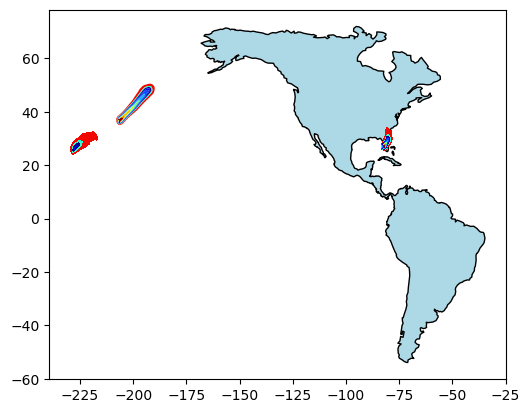

In [11]:
#Viewing location of hurricane
fig, ax = plt.subplots(1)
filtered_world.plot(ax=ax, color='lightblue', edgecolor='black')
shp.plot(ax=ax, cmap = 'jet', column = 'PERCENTAGE')

(20.0, 40.0)

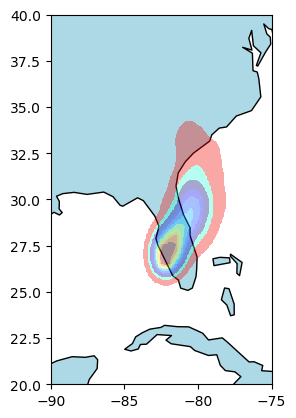

In [12]:
#Hurricane over Florida
fig, ax = plt.subplots(1)
filtered_world.plot(ax=ax, color='lightblue', edgecolor='black')
shp.plot(ax=ax, cmap = 'jet', column = 'PERCENTAGE', alpha = 0.35)

ax.set_xlim(min_lon, max_lon)
ax.set_ylim(min_lat, max_lat)

In [13]:
# # Create a GeoDataFrame from the DataFrame with Point geometries
geometry = [Point(lon, lat) for lon, lat in zip(property_df['Longitude'], property_df['Latitude'])]
house_gdf = gpd.GeoDataFrame(property_df, geometry=geometry, crs='EPSG:4326')  # assuming WGS84 coordinate reference system


(20.0, 40.0)

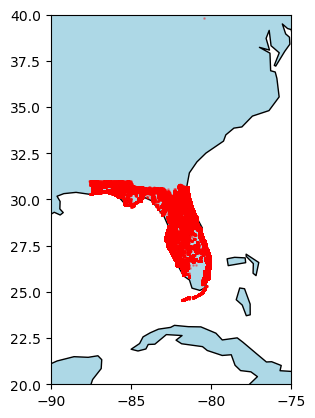

In [14]:
#Properties on Florida map
fig, ax = plt.subplots(1)
filtered_world.plot(ax=ax, color='lightblue', edgecolor='black')
house_gdf.plot(ax=ax, markersize=1, color='red', alpha=0.3)

ax.set_xlim(min_lon, max_lon)
ax.set_ylim(min_lat, max_lat)

#  Handling Missing Coordinates

In [15]:
# Handling Missing Coordinates
# Imputation of missing latitudes and longitudes based on zip codes
zip_coords = pd.read_csv('https://gist.githubusercontent.com/erichurst/7882666/raw/5bdc46db47d9515269ab12ed6fb2850377fd869e/US%20Zip%20Codes%20from%202013%20Government%20Data')
property_df = pd.merge(property_df, zip_coords, on='ZIP', how='left')
property_df['Latitude'].fillna(property_df['LAT'], inplace=True)
property_df['Longitude'].fillna(property_df['LNG'], inplace=True)
property_df.drop(['LAT', 'LNG'], axis=1, inplace=True)
property_df.head()


C:\Users\User\AppData\Local\Temp\ipykernel_25828\868774012.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  property_df['Latitude'].fillna(property_df['LAT'], inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_25828\868774012.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

,Address_Line_1,City,ZIP,County,Sale Price,Market Value,Latitude,Longitude,Property Type Code,Coverage_Building %,Coverage_Contents %,Coverage_Outbuildings %,Property Type
0,195 WINSTON LN,inlet beach,32461.0,Walton County,575100.0,1691277.0,30.254600,-85.95790,45,80,5,5,Condominiums
1,6456 AUTUMN WOODS BLVD,naples,34109.0,Collier County,397000.0,386932.0,26.218681,-81.78630,92,95,0,15,Business
2,1723 GINGER CT,middleburg,32068.0,Clay County,42900.0,123045.0,30.111518,-81.78130,109,95,15,20,Government
3,931 NAUTILUS ISLE,dania,33004.0,Broward County,125000.0,419770.0,26.061326,-80.15371,167,75,0,20,Single Family Residence
4,590 HOOKER TER,bartow,33830.0,Polk County,10500.0,59706.0,27.888814,-81.84673,45,85,5,0,Condominiums


In [16]:
# Iterate over each column and print missing data
for column in property_df.columns:
    missing_count = property_df[column].isnull().sum()
    print(f"Missing data in '{column}': {missing_count}")


Missing data in 'Address_Line_1': 0
Missing data in 'City': 25
Missing data in 'ZIP': 36
Missing data in 'County': 26
Missing data in 'Sale Price': 345623
Missing data in 'Market Value': 477
Missing data in 'Latitude': 830
Missing data in 'Longitude': 830
Missing data in 'Property Type Code': 0
Missing data in 'Coverage_Building %': 0
Missing data in 'Coverage_Contents %': 0
Missing data in 'Coverage_Outbuildings %': 0
Missing data in 'Property Type': 0


In [17]:
# Create Point geometries from Latitude and Longitude columns
geometry = [Point(xy) for xy in zip(property_df['Longitude'], property_df['Latitude'])]

# Create a GeoDataFrame with the property data and geometry column
property_gdf = gpd.GeoDataFrame(property_df, geometry=geometry, crs='EPSG:4326')

In [18]:
# Check the CRS of both GeoDataFrames
print("Property CRS:", property_gdf.crs)
print("Hurricane CRS:", shp.crs)

# Reproject the hurricane shapefile to match the property CRS (EPSG:4326 in this case)
shp = shp.to_crs(property_gdf.crs)

#Merge the Property data with hurricane path.
merged_gdf = gpd.sjoin(property_gdf, shp, how="left", predicate="within")

Property CRS: EPSG:4326
Hurricane CRS: GEOGCS["Unknown datum based upon the Authalic Sphere",DATUM["Not_specified_based_on_Authalic_Sphere",SPHEROID["Sphere",6371200,0],AUTHORITY["EPSG","6035"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [19]:
merged_gdf.head()

,Address_Line_1,City,ZIP,County,Sale Price,Market Value,Latitude,Longitude,Property Type Code,Coverage_Building %,Coverage_Contents %,Coverage_Outbuildings %,Property Type,geometry,index_right,PERCENTAGE
0,195 WINSTON LN,inlet beach,32461.0,Walton County,575100.0,1691277.0,30.254600,-85.95790,45,80,5,5,Condominiums,POINT (-85.9579 30.2546),NaN,NaN
1,6456 AUTUMN WOODS BLVD,naples,34109.0,Collier County,397000.0,386932.0,26.218681,-81.78630,92,95,0,15,Business,POINT (-81.7863 26.21868),4.0,30-40%
2,1723 GINGER CT,middleburg,32068.0,Clay County,42900.0,123045.0,30.111518,-81.78130,109,95,15,20,Government,POINT (-81.7813 30.11152),0.0,<5%
3,931 NAUTILUS ISLE,dania,33004.0,Broward County,125000.0,419770.0,26.061326,-80.15371,167,75,0,20,Single Family Residence,POINT (-80.15371 26.06133),NaN,NaN
4,590 HOOKER TER,bartow,33830.0,Polk County,10500.0,59706.0,27.888814,-81.84673,45,85,5,0,Condominiums,POINT (-81.84673 27.88881),9.0,80-90%


# Correlations

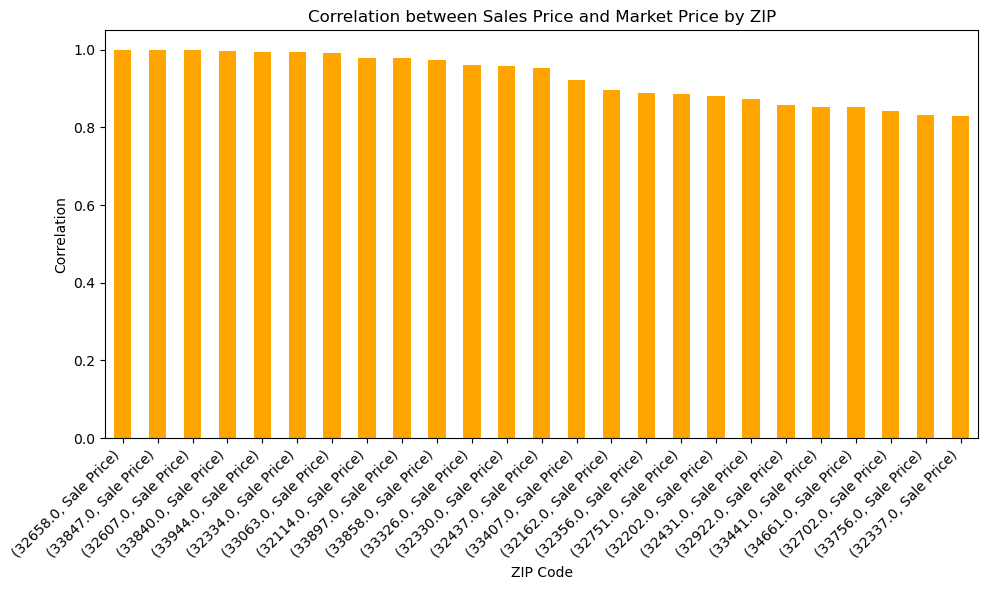

In [20]:
# Group the data by property type and calculate the correlation between sales price and market price for each group
correlation_by_zip = merged_gdf.groupby('ZIP')[['Sale Price', 'Market Value']].corr().iloc[0::2]['Market Value']

# Sort correlation values in descending order
sorted_correlation_zip = correlation_by_zip.sort_values(ascending=False)

# Plot the correlation values
plt.figure(figsize=(10, 6))
sorted_correlation_zip.head(25).plot(kind='bar', color='orange')
plt.title('Correlation between Sales Price and Market Price by ZIP')
plt.xlabel('ZIP Code')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

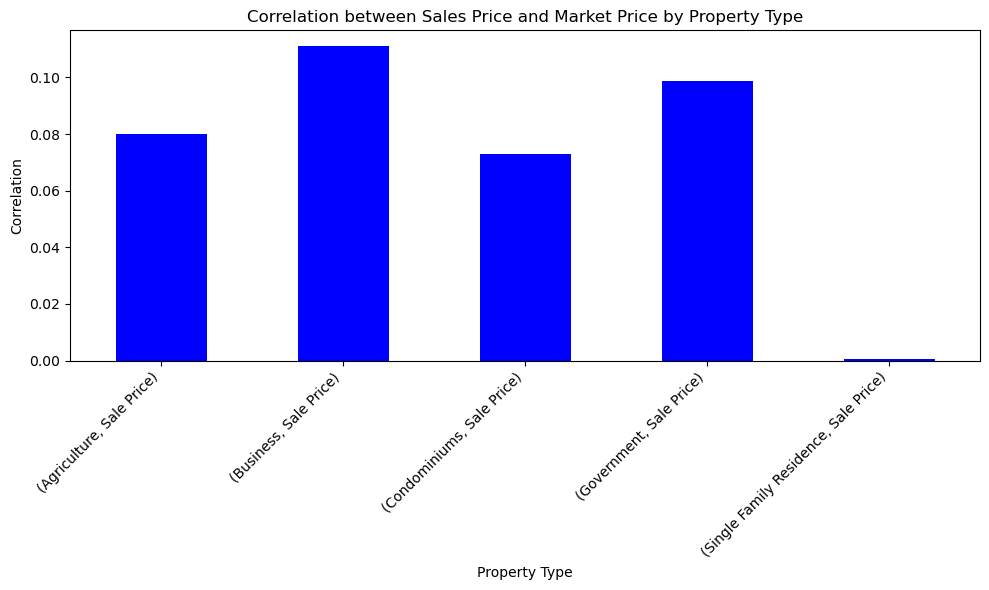

In [21]:
# Group the data by property type and calculate the correlation between sales price and market price for each group
correlation_by_property_type = merged_gdf.groupby('Property Type')[['Sale Price', 'Market Value']].corr().iloc[0::2]['Market Value']

# Plot the correlation values
plt.figure(figsize=(10, 6))
correlation_by_property_type.plot(kind='bar', color='blue')
plt.title('Correlation between Sales Price and Market Price by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Property Type have Low correlation with Market Value and Sale Price than ZIP code due to outliers

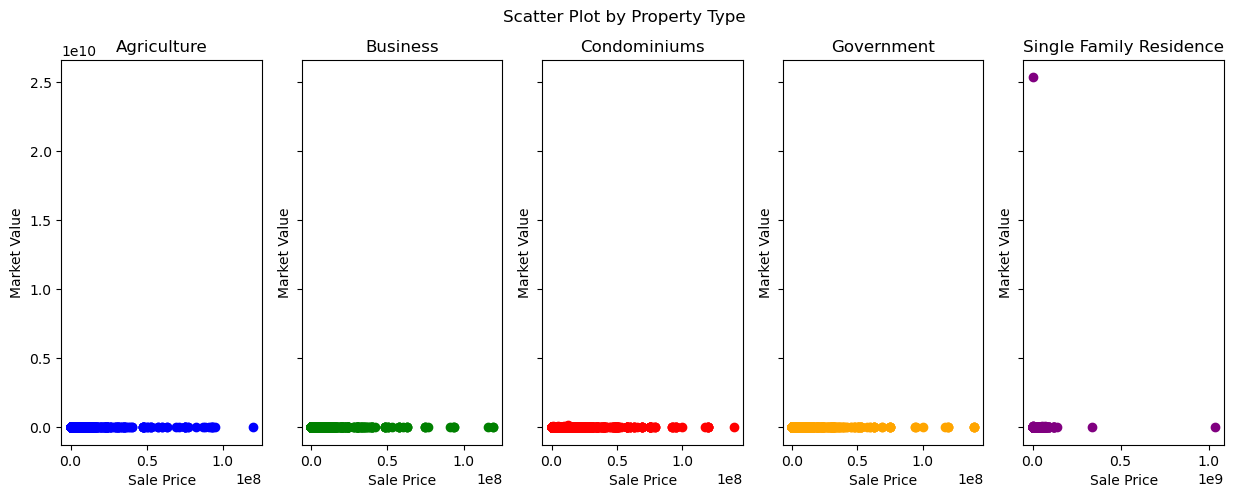

In [22]:
#Correlation of Market and Sale Price for each Property Type
grouped_property = merged_gdf.groupby('Property Type')

# Define colors for each property type
colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']

# Create subplots
fig, axs = plt.subplots(1, len(grouped_property), figsize=(15, 5), sharey=True)

# Plot scatter plots for each group with different colors
for i, (property_type, group_data) in enumerate(grouped_property):
    axs[i].scatter(group_data['Sale Price'], group_data['Market Value'], color=colors[i])
    axs[i].set_title(property_type)
    axs[i].set_xlabel('Sale Price')
    axs[i].set_ylabel('Market Value')

# Add overall title
fig.suptitle('Scatter Plot by Property Type')

# Show plot
plt.show()

# Removing Duplicate Addresses

In [23]:
# Keeping the latest entry for address
removed_duplicates = merged_gdf.drop_duplicates(subset=['Address_Line_1'], keep='last')

In [24]:
removed_duplicates.head()

,Address_Line_1,City,ZIP,County,Sale Price,Market Value,Latitude,Longitude,Property Type Code,Coverage_Building %,Coverage_Contents %,Coverage_Outbuildings %,Property Type,geometry,index_right,PERCENTAGE
0,195 WINSTON LN,inlet beach,32461.0,Walton County,575100.0,1691277.0,30.254600,-85.95790,45,80,5,5,Condominiums,POINT (-85.9579 30.2546),NaN,NaN
1,6456 AUTUMN WOODS BLVD,naples,34109.0,Collier County,397000.0,386932.0,26.218681,-81.78630,92,95,0,15,Business,POINT (-81.7863 26.21868),4.0,30-40%
2,1723 GINGER CT,middleburg,32068.0,Clay County,42900.0,123045.0,30.111518,-81.78130,109,95,15,20,Government,POINT (-81.7813 30.11152),0.0,<5%
3,931 NAUTILUS ISLE,dania,33004.0,Broward County,125000.0,419770.0,26.061326,-80.15371,167,75,0,20,Single Family Residence,POINT (-80.15371 26.06133),NaN,NaN
4,590 HOOKER TER,bartow,33830.0,Polk County,10500.0,59706.0,27.888814,-81.84673,45,85,5,0,Condominiums,POINT (-81.84673 27.88881),9.0,80-90%


# Outlier Detection and Removal

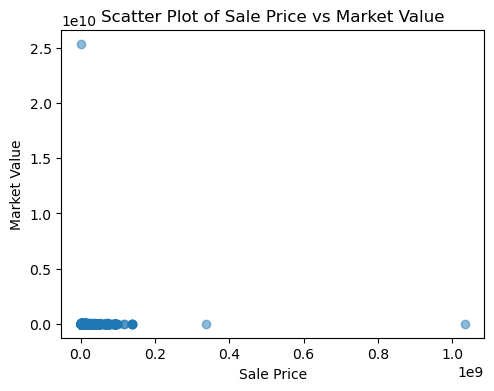

In [25]:
#Scatter Plot of Sale Price vs Market Value
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(removed_duplicates['Sale Price'], removed_duplicates['Market Value'], alpha=0.5)
plt.xlabel('Sale Price')
plt.ylabel('Market Value')
plt.title('Scatter Plot of Sale Price vs Market Value')

plt.show()


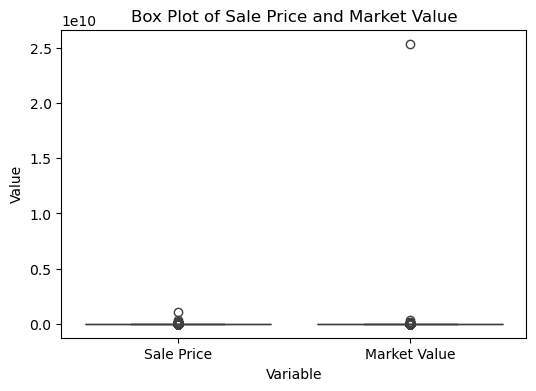

In [26]:
#Box Plot of Sale Price and Market Value to see the outliers
plt.figure(figsize=(6, 4))

# Create box plots using Seaborn
sns.boxplot(data=removed_duplicates[['Sale Price', 'Market Value']])

# Set labels and title
plt.xlabel('Variable')
plt.ylabel('Value')
plt.title('Box Plot of Sale Price and Market Value')

# Show plot
plt.show()


Text(0.5, 1.0, 'Distribution of Market Value')

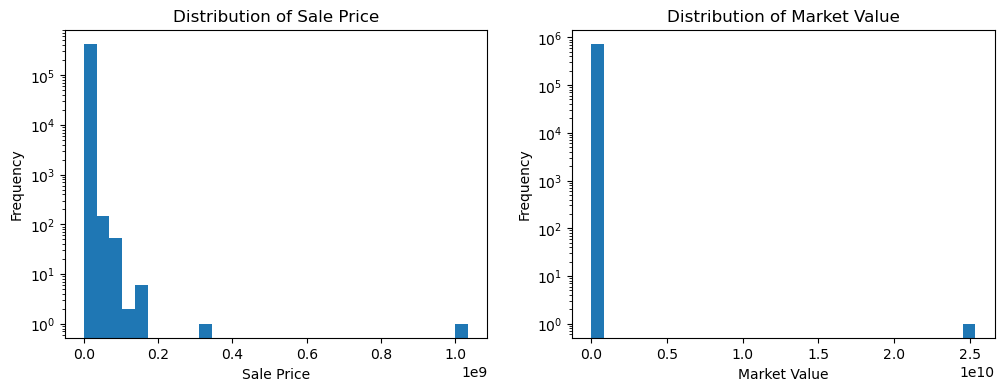

In [27]:
#Distribution of Sale Price and Market Value before outlier removal
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(removed_duplicates['Sale Price'], bins=30)
plt.yscale('log')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Distribution of Sale Price')

plt.subplot(1, 2, 2)
plt.hist(removed_duplicates['Market Value'], bins=30)
plt.yscale('log')
plt.xlabel('Market Value')
plt.ylabel('Frequency')
plt.title('Distribution of Market Value')

In [28]:
#Outlier detection and Replacing with median
Q1, Q3 = removed_duplicates['Sale Price'].quantile([0.025, 0.975])
IQR = Q3 - Q1

outliers = (removed_duplicates['Sale Price'] < Q1 - (1.5 * IQR)) | (removed_duplicates['Sale Price'] > Q3 + (1.5 * IQR))

median_nonOutlierSale = removed_duplicates.loc[~outliers, 'Sale Price'].median()

removed_duplicates.loc[outliers, 'Sale Price'] = median_nonOutlierSale

In [29]:
#Outlier detection and Replacing with median
Q1, Q3 = removed_duplicates['Market Value'].quantile([0.025, 0.975])
IQR = Q3 - Q1

outliers = (removed_duplicates['Market Value'] < Q1 - (1.5 * IQR)) | (removed_duplicates['Market Value'] > Q3 + (1.5 * IQR))

median_nonOutlierMarket = removed_duplicates.loc[~outliers, 'Market Value'].median()

removed_duplicates.loc[outliers, 'Market Value'] = median_nonOutlierMarket

In [30]:
#Replacing Sale Price and Market Value with above median where both values are null 
na_replacement = {'Sale Price':median_nonOutlierSale, 'Market Value':median_nonOutlierMarket}
removed_duplicates = removed_duplicates.fillna(na_replacement)

In [31]:
removed_duplicates.head()

,Address_Line_1,City,ZIP,County,Sale Price,Market Value,Latitude,Longitude,Property Type Code,Coverage_Building %,Coverage_Contents %,Coverage_Outbuildings %,Property Type,geometry,index_right,PERCENTAGE
0,195 WINSTON LN,inlet beach,32461.0,Walton County,575100.0,1691277.0,30.254600,-85.95790,45,80,5,5,Condominiums,POINT (-85.9579 30.2546),NaN,NaN
1,6456 AUTUMN WOODS BLVD,naples,34109.0,Collier County,397000.0,386932.0,26.218681,-81.78630,92,95,0,15,Business,POINT (-81.7863 26.21868),4.0,30-40%
2,1723 GINGER CT,middleburg,32068.0,Clay County,42900.0,123045.0,30.111518,-81.78130,109,95,15,20,Government,POINT (-81.7813 30.11152),0.0,<5%
3,931 NAUTILUS ISLE,dania,33004.0,Broward County,125000.0,419770.0,26.061326,-80.15371,167,75,0,20,Single Family Residence,POINT (-80.15371 26.06133),NaN,NaN
4,590 HOOKER TER,bartow,33830.0,Polk County,10500.0,59706.0,27.888814,-81.84673,45,85,5,0,Condominiums,POINT (-81.84673 27.88881),9.0,80-90%


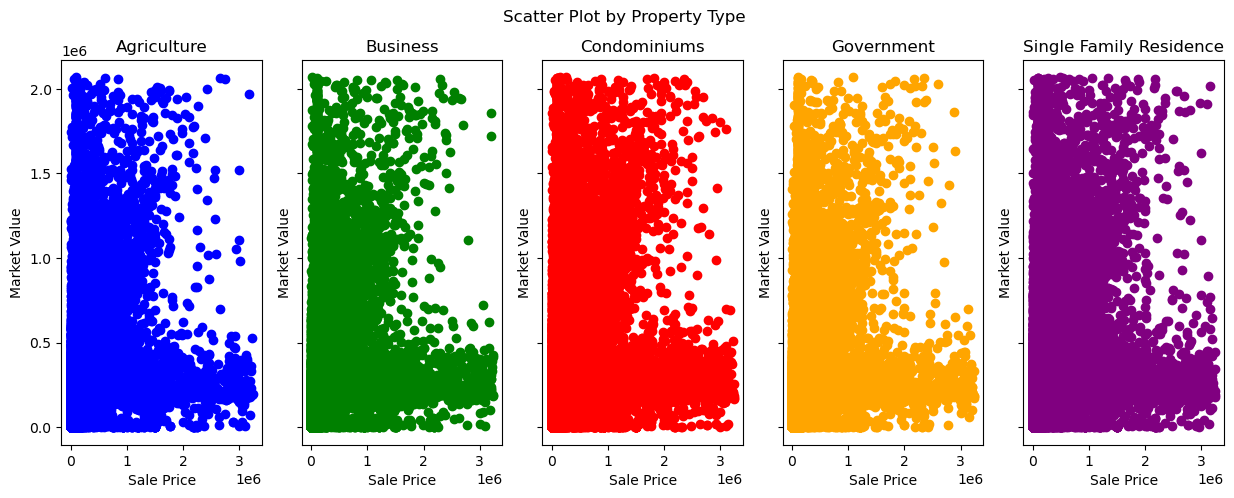

Correlation between Sales Price and Market Price by Property Type:
Property Type                      
Agriculture              Sale Price    0.287679
Business                 Sale Price    0.291911
Condominiums             Sale Price    0.301432
Government               Sale Price    0.288116
Single Family Residence  Sale Price    0.293066
Name: Market Value, dtype: float64



In [32]:
grouped_property = removed_duplicates.groupby('Property Type')

# Define colors for each property type
colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']

# Create subplots
fig, axs = plt.subplots(1, len(grouped_property), figsize=(15, 5), sharey=True)

# Plot scatter plots for each group with different colors
for i, (property_type, group_data) in enumerate(grouped_property):
    axs[i].scatter(group_data['Sale Price'], group_data['Market Value'], color=colors[i])
    axs[i].set_title(property_type)
    axs[i].set_xlabel('Sale Price')
    axs[i].set_ylabel('Market Value')

# Add overall title
fig.suptitle('Scatter Plot by Property Type')

# Show plot
plt.show()
# Group the data by property type and calculate the correlation between sales price and market price for each group
correlation_by_property_type = removed_duplicates.groupby('Property Type')[['Sale Price', 'Market Value']].corr().iloc[0::2]['Market Value']
# Print the correlation for each property type
print("Correlation between Sales Price and Market Price by Property Type:")
print(correlation_by_property_type)
print()


Text(0.5, 1.0, 'Distribution of Market Value')

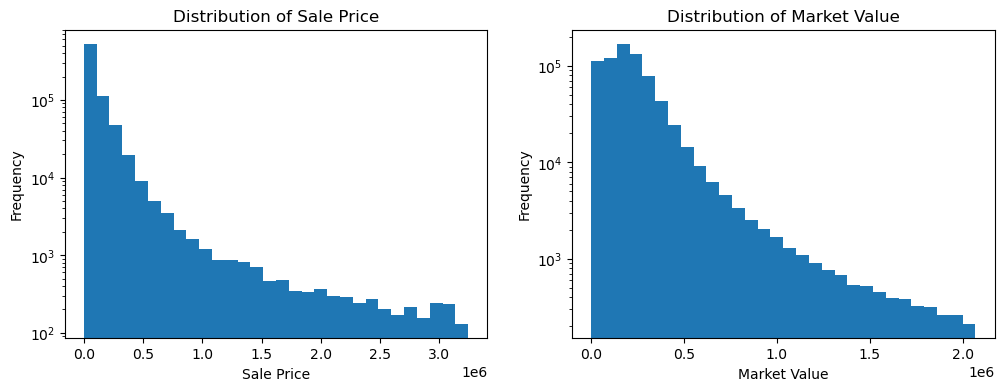

In [33]:
#Distribution of Sale Price and Market Value after outlier removal
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(removed_duplicates['Sale Price'], bins=30)
plt.yscale('log')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Distribution of Sale Price')

plt.subplot(1, 2, 2)
plt.hist(removed_duplicates['Market Value'], bins=30)
plt.yscale('log')
plt.xlabel('Market Value')
plt.ylabel('Frequency')
plt.title('Distribution of Market Value')

C:\Users\User\AppData\Local\Temp\ipykernel_25828\1180932206.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([removed_duplicates['Sale Price'], removed_duplicates['Market Value']], labels=['Sale Price', 'Market Value'])


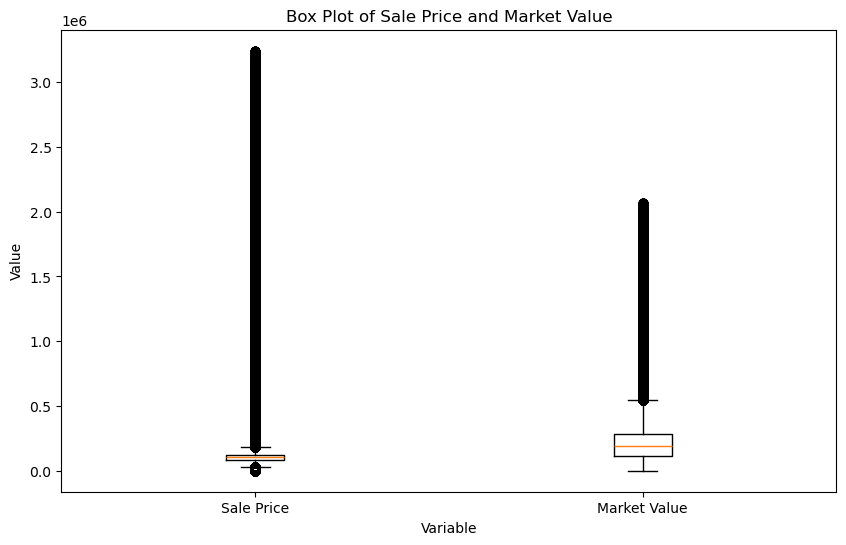

In [34]:
#Box Plot of Sale Price and Market Value after outliers removal
plt.figure(figsize=(10,6))

# Create box plots for Sale Price and Market Value
plt.boxplot([removed_duplicates['Sale Price'], removed_duplicates['Market Value']], labels=['Sale Price', 'Market Value'])

# Set labels and title
plt.xlabel('Variable')
plt.ylabel('Value')
plt.title('Box Plot of Sale Price and Market Value')

# Show plot
plt.show()


# Filtering Data Based on Percentage and Property Type

In [51]:
#Filtering for risk percentage
risk_percentage = ['60-70%', '70-80%', '80-90%', '>90%']
risk_property_df = removed_duplicates[removed_duplicates['PERCENTAGE'].isin(risk_percentage)]
removed_duplicates.to_csv("KDC_Hurricane_Impact.csv", index=False)

In [36]:
#Filtering by property type
property_type = ['Condominiums', 'Single Family Residence'] 
selected_property_df = risk_property_df[risk_property_df['Property Type'].isin(property_type)]
selected_property_df

,Address_Line_1,City,ZIP,County,Sale Price,Market Value,Latitude,Longitude,Property Type Code,Coverage_Building %,Coverage_Contents %,Coverage_Outbuildings %,Property Type,geometry,index_right,PERCENTAGE
4,590 HOOKER TER,bartow,33830.0,Polk County,10500.0,59706.0,27.888814,-81.846730,45,85,5,0,Condominiums,POINT (-81.84673 27.88881),9.0,80-90%
71,401 OCONEE ST,lakeland,33805.0,Polk County,16000.0,124507.0,28.070898,-81.954060,167,90,15,0,Single Family Residence,POINT (-81.95406 28.0709),7.0,60-70%
98,1735 PLANTATION POINTE DR,orlando,32824.0,Orange County,105000.0,286698.0,28.382236,-81.351500,45,85,15,0,Condominiums,POINT (-81.3515 28.38224),7.0,60-70%
104,2574 ASTER COVE LN,kissimmee,34758.0,Osceola County,105000.0,229700.0,28.227478,-81.496270,45,95,10,10,Condominiums,POINT (-81.49627 28.22748),8.0,70-80%
108,1528 SW 29TH ST,cape coral,33914.0,Lee County,105000.0,201839.0,26.598176,-82.005870,45,75,5,5,Condominiums,POINT (-82.00587 26.59818),10.0,>90%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821490,2532 PALM TREE DR,kissimmee,34759.0,Polk County,105000.0,172500.0,28.135269,-81.487130,45,80,10,20,Condominiums,POINT (-81.48713 28.13527),8.0,70-80%
821503,2551 EAGLE BAY BLVD,kissimmee,34743.0,Osceola County,105000.0,236500.0,28.337047,-81.338760,45,95,0,15,Condominiums,POINT (-81.33876 28.33705),7.0,60-70%
821509,3910 WILLOW HAMMOCK DR,palmetto,34221.0,Manatee County,3040000.0,199157.0,27.581094,-82.554803,167,90,15,10,Single Family Residence,POINT (-82.5548 27.58109),7.0,60-70%
821515,7798 PLANTATION CIR,bradenton,34201.0,Manatee County,97000.0,143000.0,27.397566,-82.462470,45,75,0,0,Condominiums,POINT (-82.46247 27.39757),10.0,>90%


In [37]:
# Iterate over each column and print missing data
for column in risk_property_df.columns:
    missing_count = risk_property_df[column].isnull().sum()
    print(f"Missing data in '{column}': {missing_count}")

Missing data in 'Address_Line_1': 0
Missing data in 'City': 0
Missing data in 'ZIP': 0
Missing data in 'County': 0
Missing data in 'Sale Price': 0
Missing data in 'Market Value': 0
Missing data in 'Latitude': 0
Missing data in 'Longitude': 0
Missing data in 'Property Type Code': 0
Missing data in 'Coverage_Building %': 0
Missing data in 'Coverage_Contents %': 0
Missing data in 'Coverage_Outbuildings %': 0
Missing data in 'Property Type': 0
Missing data in 'geometry': 0
Missing data in 'index_right': 0
Missing data in 'PERCENTAGE': 0


# Identifying Geographic Impact Concentration

In [38]:
## Top 5 Zip Codes with count of Risk properties.
zip_code_df = risk_property_df.groupby('ZIP').size().reset_index(name='Number of Properties')
zip_code_df = zip_code_df.sort_values(by='Number of Properties', ascending=False)
zip_code_df.head()

,ZIP,Number of Properties
56,33852.0,2878
171,34293.0,2693
126,33993.0,2596
90,33914.0,2212
121,33981.0,2197


In [39]:
## Top 5 Zip Codes with count of only 'Condominiums', 'Single Family Residence' Risk properties.
zip_code_df_selected = selected_property_df.groupby('ZIP').size().reset_index(name='Number of Properties')
zip_code_df_selected = zip_code_df_selected.sort_values(by='Number of Properties', ascending=False)
zip_code_df_selected.head()

,ZIP,Number of Properties
52,33852.0,1621
166,34293.0,1584
121,33993.0,1474
116,33981.0,1267
86,33914.0,1252


In [40]:
zip_codes = [33852.0, 34293.0, 33993.0, 33981.0, 33914.0]
five_zip_code_loc = risk_property_df[risk_property_df['ZIP'].isin(zip_codes)]

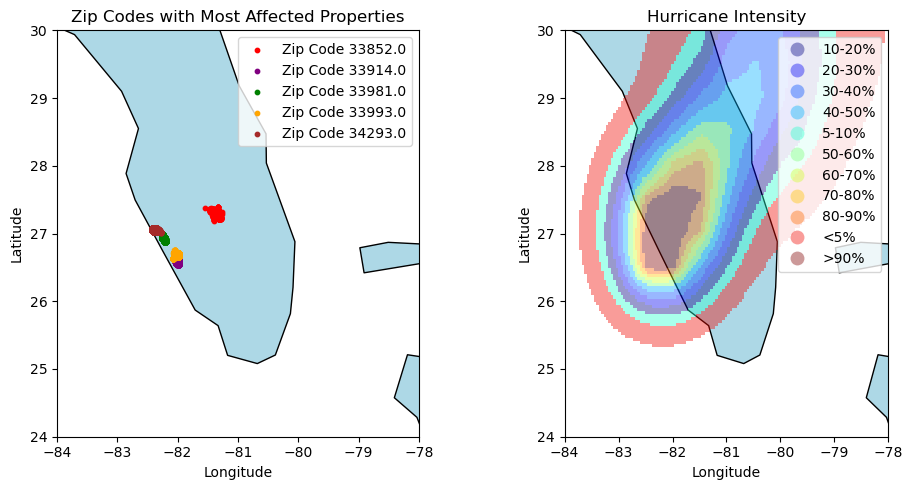

In [41]:
colors = ['red', 'purple', 'green', 'orange', 'brown']

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot the first subplot
filtered_world.plot(ax=axs[0], color='lightblue', edgecolor='black')

# Plot each zip code with a different color
for i, (ZIP, data) in enumerate(five_zip_code_loc.groupby('ZIP')):
    data.plot(ax=axs[0], color=colors[i], markersize=10, label=f'Zip Code {ZIP}')

# Plot the second subplot
filtered_world.plot(ax=axs[1], color='lightblue', edgecolor='black')
shp.plot(ax=axs[1], cmap='jet', column='PERCENTAGE', alpha=0.4, legend=True)

# Set common x and y limits for both subplots
for ax in axs:
    ax.set_xlim(-84, -78)
    ax.set_ylim(24, 30)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# Add titles and legends
axs[0].set_title('Zip Codes with Most Affected Properties')
axs[0].legend()
axs[1].set_title('Hurricane Intensity')

plt.tight_layout()

plt.show()


C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


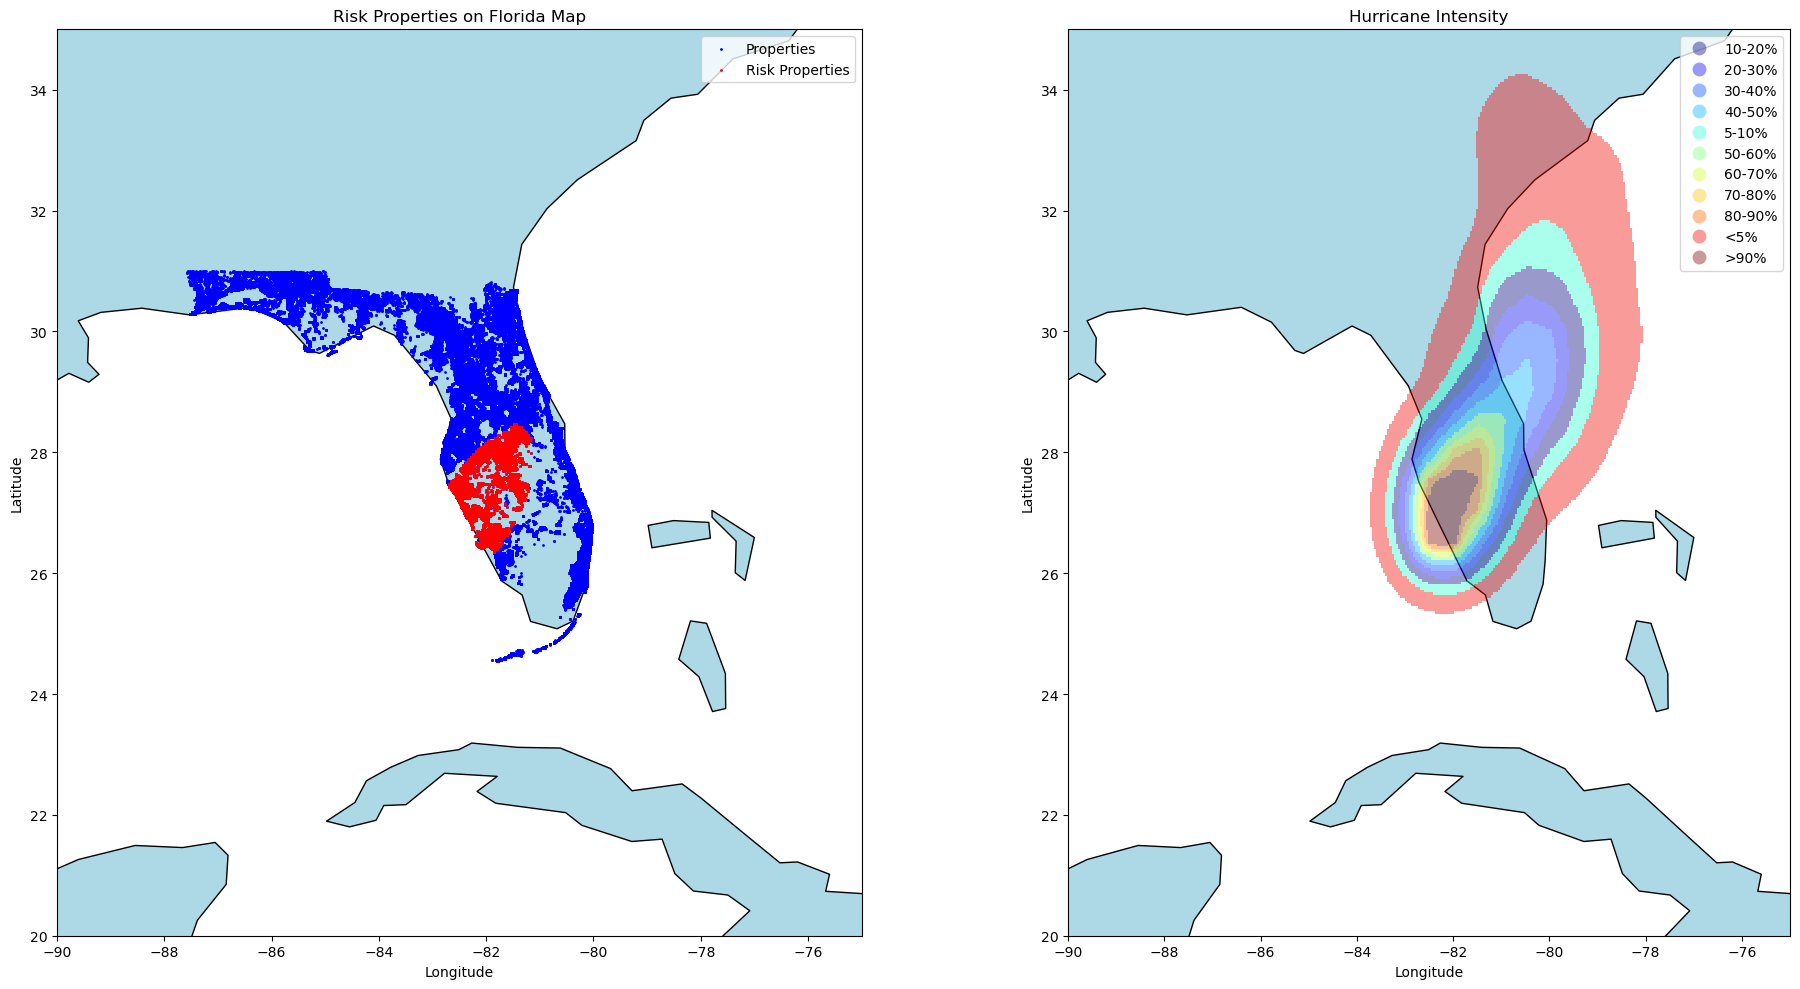

In [42]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))

# Plot the first subplot
filtered_world.plot(ax=axs[0], color='lightblue', edgecolor='black')
property_gdf.plot(ax=axs[0], color='blue', markersize=1, label='Properties')
risk_property_df.plot(ax=axs[0], color='red', markersize=1, label='Risk Properties')

# Plot the second subplot
filtered_world.plot(ax=axs[1], color='lightblue', edgecolor='black')
shp.plot(ax=axs[1], cmap='jet', column='PERCENTAGE', alpha=0.4, legend=True)

# Set common x and y limits for both subplots
for ax in axs:
    ax.set_xlim(min_lon, max_lon)
    ax.set_ylim(min_lat, max_lat - 5)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# Add titles and legends
axs[0].set_title('Risk Properties on Florida Map')
axs[0].legend()
axs[1].set_title('Hurricane Intensity')

plt.tight_layout()

plt.show()


Above plot describes that we have identified correct risk properties as it matches the hurricane intensity.

# Determining the Maximum Exposure for KDC

In [43]:
# Make sure we are working on a copy to avoid SettingWithCopyWarning
risk_property_df = risk_property_df.copy()
#Selecting max value
risk_property_df['Property Value'] = risk_property_df[['Market Value', 'Sale Price']].max(axis = 1)
#Adding coverages and potential exposure
risk_property_df['Building Coverage'] = (risk_property_df['Property Value'] * risk_property_df['Coverage_Building %']) / 100
risk_property_df['Contents Coverage'] = (risk_property_df['Building Coverage'] * risk_property_df['Coverage_Contents %']) / 100
risk_property_df['Outbuilding Coverage'] = (risk_property_df['Building Coverage'] * risk_property_df['Coverage_Outbuildings %']) / 100
risk_property_df['Total Exposure Cost'] = risk_property_df['Building Coverage'] + risk_property_df['Contents Coverage'] + risk_property_df['Outbuilding Coverage']

In [44]:
risk_property_df.head()

,Address_Line_1,City,ZIP,County,Sale Price,Market Value,Latitude,Longitude,Property Type Code,Coverage_Building %,...,Coverage_Outbuildings %,Property Type,geometry,index_right,PERCENTAGE,Property Value,Building Coverage,Contents Coverage,Outbuilding Coverage,Total Exposure Cost
4,590 HOOKER TER,bartow,33830.0,Polk County,10500.0,59706.0,27.888814,-81.84673,45,85,...,0,Condominiums,POINT (-81.84673 27.88881),9.0,80-90%,59706.0,50750.1,2537.505,0.000,53287.605
24,803 MONTROSE DR,venice,34293.0,Sarasota County,105000.0,128900.0,27.072881,-82.35919,2,85,...,15,Agriculture,POINT (-82.35919 27.07288),10.0,>90%,128900.0,109565.0,5478.250,16434.750,131478.000
33,3904 SW 2ND ST,cape coral,33991.0,Lee County,532500.0,441934.0,26.648783,-82.05512,2,85,...,0,Agriculture,POINT (-82.05512 26.64878),10.0,>90%,532500.0,452625.0,0.000,0.000,452625.000
46,711 ALTMAN RD,wauchula,33873.0,Hardee County,105000.0,177970.0,27.530704,-81.83302,109,85,...,15,Government,POINT (-81.83302 27.5307),10.0,>90%,177970.0,151274.5,22691.175,22691.175,196656.850
49,5781 LINDEN LN,bokeelia,33922.0,Lee County,129000.0,25300.0,26.662200,-82.13310,92,95,...,15,Business,POINT (-82.1331 26.6622),10.0,>90%,129000.0,122550.0,12255.000,18382.500,153187.500


In [45]:
# Make sure we are working on a copy to avoid SettingWithCopyWarning
selected_property_df = selected_property_df.copy()
#Selecting max value
selected_property_df['Property Value'] = selected_property_df[['Market Value', 'Sale Price']].max(axis = 1)
#Adding coverages and potential exposure
selected_property_df['Building Coverage'] = (selected_property_df['Property Value'] * selected_property_df['Coverage_Building %']) / 100
selected_property_df['Contents Coverage'] = (selected_property_df['Building Coverage'] * selected_property_df['Coverage_Contents %']) / 100
selected_property_df['Outbuilding Coverage'] = (selected_property_df['Building Coverage'] * selected_property_df['Coverage_Outbuildings %']) / 100
selected_property_df['Total Exposure Cost'] = selected_property_df['Building Coverage'] + selected_property_df['Contents Coverage'] + selected_property_df['Outbuilding Coverage']

In [46]:
selected_property_df.head()

,Address_Line_1,City,ZIP,County,Sale Price,Market Value,Latitude,Longitude,Property Type Code,Coverage_Building %,...,Coverage_Outbuildings %,Property Type,geometry,index_right,PERCENTAGE,Property Value,Building Coverage,Contents Coverage,Outbuilding Coverage,Total Exposure Cost
4,590 HOOKER TER,bartow,33830.0,Polk County,10500.0,59706.0,27.888814,-81.84673,45,85,...,0,Condominiums,POINT (-81.84673 27.88881),9.0,80-90%,59706.0,50750.10,2537.5050,0.0000,53287.605
71,401 OCONEE ST,lakeland,33805.0,Polk County,16000.0,124507.0,28.070898,-81.95406,167,90,...,0,Single Family Residence,POINT (-81.95406 28.0709),7.0,60-70%,124507.0,112056.30,16808.4450,0.0000,128864.745
98,1735 PLANTATION POINTE DR,orlando,32824.0,Orange County,105000.0,286698.0,28.382236,-81.35150,45,85,...,0,Condominiums,POINT (-81.3515 28.38224),7.0,60-70%,286698.0,243693.30,36553.9950,0.0000,280247.295
104,2574 ASTER COVE LN,kissimmee,34758.0,Osceola County,105000.0,229700.0,28.227478,-81.49627,45,95,...,10,Condominiums,POINT (-81.49627 28.22748),8.0,70-80%,229700.0,218215.00,21821.5000,21821.5000,261858.000
108,1528 SW 29TH ST,cape coral,33914.0,Lee County,105000.0,201839.0,26.598176,-82.00587,45,75,...,5,Condominiums,POINT (-82.00587 26.59818),10.0,>90%,201839.0,151379.25,7568.9625,7568.9625,166517.175


In [47]:
#Calculate Total Coverage and Total Exposure Cost
Total_Building_Coverage = risk_property_df['Building Coverage'].sum()
formatted_Total_Building_Coverage = "{:,.2f}".format(Total_Building_Coverage)
Total_Contents_Coverage = risk_property_df['Contents Coverage'].sum()
formatted_Total_Contents_Coverage = "{:,.2f}".format(Total_Contents_Coverage)
Total_Outbuilding_Coverage = risk_property_df['Outbuilding Coverage'].sum()
formatted_Total_Outbuilding_Coverage = "{:,.2f}".format(Total_Outbuilding_Coverage)
Total_Cost = risk_property_df['Total Exposure Cost'].sum()
formatted_total_cost = "{:,.2f}".format(Total_Cost)  # Format the total cost with commas and two decimal places
print(f'Total Building Coverage for all affected properties >60% is: ${formatted_Total_Building_Coverage}')
print(f'Total Contents Coverage for all affected properties >60% is: ${formatted_Total_Contents_Coverage}')
print(f'Total Outbuilding Coverage for all affected properties >60% is: ${formatted_Total_Outbuilding_Coverage}')
print(f'Total Exposure Cost for all affected properties >60% is: ${formatted_total_cost}')

Total Building Coverage for all affected properties >60% is: $29,050,139,002.88
Total Contents Coverage for all affected properties >60% is: $2,181,064,656.41
Total Outbuilding Coverage for all affected properties >60% is: $2,912,158,872.84
Total Exposure Cost for all affected properties >60% is: $34,143,362,532.13


In [48]:
#Calculate Total Coverage and Total Exposure Cost
Total_Building_Coverage = selected_property_df['Building Coverage'].sum()
formatted_Total_Building_Coverage = "{:,.2f}".format(Total_Building_Coverage)
Total_Contents_Coverage = selected_property_df['Contents Coverage'].sum()
formatted_Total_Contents_Coverage = "{:,.2f}".format(Total_Contents_Coverage)
Total_Outbuilding_Coverage = selected_property_df['Outbuilding Coverage'].sum()
formatted_Total_Outbuilding_Coverage = "{:,.2f}".format(Total_Outbuilding_Coverage)
Total_Cost_selected = selected_property_df['Total Exposure Cost'].sum()
formatted_selected_total_cost = "{:,.2f}".format(Total_Cost_selected)  # Format the total cost with commas and two decimal places
print(f'Total Building Coverage for all affected properties >60% is: ${formatted_Total_Building_Coverage}')
print(f'Total Contents Coverage for all affected properties >60% is: ${formatted_Total_Contents_Coverage}')
print(f'Total Outbuilding Coverage for all affected properties >60% is: ${formatted_Total_Outbuilding_Coverage}')
print(f'Total Cost for only Condominiums and Single Family Residence affected properties >60% is: ${formatted_selected_total_cost}')

Total Building Coverage for all affected properties >60% is: $16,625,768,689.83
Total Contents Coverage for all affected properties >60% is: $1,249,551,546.98
Total Outbuilding Coverage for all affected properties >60% is: $1,665,088,192.24
Total Cost for only Condominiums and Single Family Residence affected properties >60% is: $19,540,408,429.06


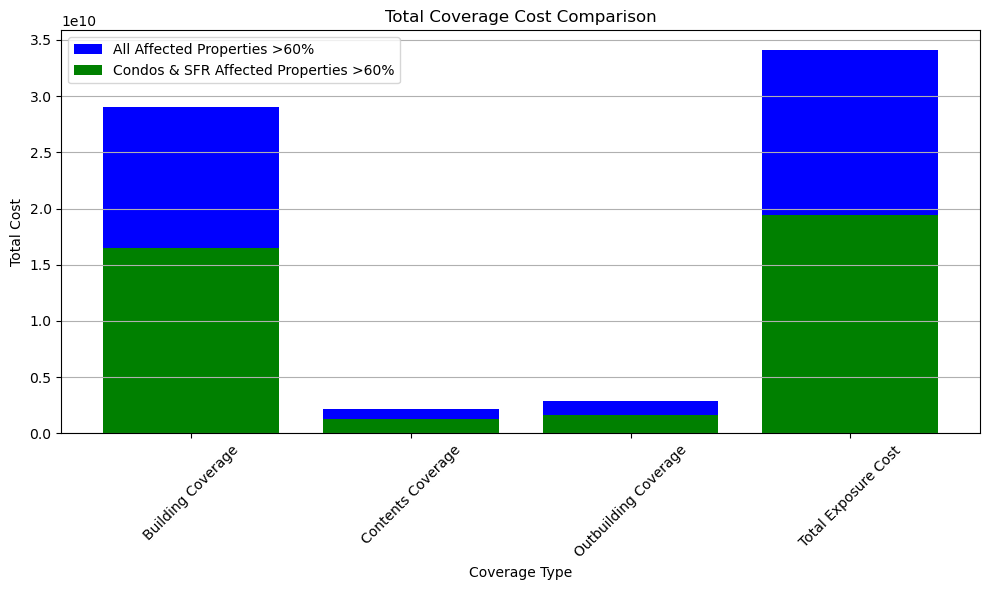

In [49]:
import matplotlib.pyplot as plt

# Data
coverage_labels = ['Building Coverage', 'Contents Coverage', 'Outbuilding Coverage', 'Total Exposure Cost']
coverage_values_all = [29051999313.48, 2181632147.23, 2912386742.98, 34146018203.68]
coverage_values_condo_sfr = [16530735143.48, 1241239605.79, 1655866007.39, 19427840756.66]

# Plot
plt.figure(figsize=(10, 6))

plt.bar(coverage_labels, coverage_values_all, color='blue', label='All Affected Properties >60%')
plt.bar(coverage_labels, coverage_values_condo_sfr, color='green', label='Condos & SFR Affected Properties >60%')

plt.xlabel('Coverage Type')
plt.ylabel('Total Cost')
plt.title('Total Coverage Cost Comparison')
plt.legend()
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()
